<a href="https://www.kaggle.com/code/avikdas567/github-ai-ecosystem-analysis-and-insights?scriptVersionId=321716858" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>


# GitHub AI Repositories Intelligence Report

## Decoding the Open Source AI Ecosystem Through GitHub Signals

The modern AI ecosystem is being built in public. From foundational LLM frameworks and vector databases to multimodal research repositories and agent tooling, GitHub has become the central coordination layer for open-source AI development.

This notebook analyzes 2,853 trending AI and Machine Learning repositories collected from GitHub. The dataset contains repository popularity metrics, activity signals, contributor statistics, repository metadata, licensing information, programming languages, and topic tags.

The analysis combines:

- Exploratory Data Analysis
- Statistical analysis
- NLP techniques
- Machine Learning
- Clustering
- Recommendation systems
- Topic network analysis
- Ecosystem intelligence

The goal is not only to understand which repositories are popular, but also to uncover the hidden patterns driving growth, adoption, developer engagement, and ecosystem momentum across the AI landscape.

In [1]:
# Environment Setup

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression

from sklearn.manifold import TSNE

import networkx as nx

sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

In [2]:
# Load Dataset

DATA_PATH = "/kaggle/input/datasets/patelris/github-top-aiml-repositories-dataset-2026/github_ai_repos_2026.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
display(df.head())

Dataset Shape: (2853, 24)


,full_name,name,owner,description,stars,forks,watchers,open_issues,language,license,...,size_kb,default_branch,is_fork,archived,has_wiki,has_pages,contributors,commits_last_4w,commits_last_52w,html_url
0,tensorflow/tensorflow,tensorflow,tensorflow,An Open Source Machine Learning Framework for ...,194766,75283,194766,4455,C++,Apache-2.0,...,1307558,master,False,False,False,False,5053.0,1039.0,13310.0,https://github.com/tensorflow/tensorflow
1,Significant-Gravitas/AutoGPT,AutoGPT,Significant-Gravitas,AutoGPT is the vision of accessible AI for eve...,183489,46223,183489,382,Python,NOASSERTION,...,510366,master,False,False,True,False,812.0,NaN,NaN,https://github.com/Significant-Gravitas/AutoGPT
2,ollama/ollama,ollama,ollama,"Get up and running with Kimi-K2.5, GLM-5, Mini...",169211,15631,169211,2959,Go,MIT,...,78924,main,False,False,False,False,597.0,NaN,NaN,https://github.com/ollama/ollama
3,f/prompts.chat,prompts.chat,f,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",159897,20939,159897,43,HTML,NOASSERTION,...,312378,main,False,False,True,True,963.0,NaN,NaN,https://github.com/f/prompts.chat
4,huggingface/transformers,transformers,huggingface,🤗 Transformers: the model-definition framework...,159495,32895,159495,2352,Python,Apache-2.0,...,466632,main,False,False,True,False,3878.0,318.0,5212.0,https://github.com/huggingface/transformers



# Dataset Overview

The dataset contains metadata and engagement statistics for AI-related repositories on GitHub.

Key repository signals available in this dataset:

- Popularity metrics
- Development activity
- Community participation
- Programming languages
- Licensing
- Topic tags
- Repository descriptions
- Contributor information
- Maintenance signals

This combination makes the dataset suitable for:

- Statistical analysis
- Trend forecasting
- Recommendation systems
- NLP pipelines
- Machine learning modeling
- Ecosystem mapping


In [3]:
# Dataset Information

display(df.info())

display(df.describe(include="all").T.head(20))

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_values")
)

missing["missing_percent"] = (missing["missing_values"] / len(df)) * 100

display(missing)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2853 entries, 0 to 2852
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   full_name         2853 non-null   object 
 1   name              2853 non-null   object 
 2   owner             2853 non-null   object 
 3   description       2824 non-null   object 
 4   stars             2853 non-null   int64  
 5   forks             2853 non-null   int64  
 6   watchers          2853 non-null   int64  
 7   open_issues       2853 non-null   int64  
 8   language          2502 non-null   object 
 9   license           2283 non-null   object 
 10  topics            2036 non-null   object 
 11  created_at        2853 non-null   object 
 12  updated_at        2853 non-null   object 
 13  pushed_at         2853 non-null   object 
 14  size_kb           2853 non-null   int64  
 15  default_branch    2853 non-null   object 
 16  is_fork           2853 non-null   bool   


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
full_name,2853,2853,andriyadi/Maix-SpeechRecognizer,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,2853,2808,DeepLearning,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
owner,2853,2273,microsoft,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,2824,2821,"This SDK is now deprecated, use the unified Fi...",3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stars,2853.0,NaN,NaN,NaN,6728.892744,15605.033438,52.0,439.0,1280.0,5911.0,194766.0
forks,2853.0,NaN,NaN,NaN,1127.130039,3444.936824,0.0,61.0,198.0,867.0,75283.0
watchers,2853.0,NaN,NaN,NaN,6728.892744,15605.033438,52.0,439.0,1280.0,5911.0,194766.0
open_issues,2853.0,NaN,NaN,NaN,96.534876,315.402009,0.0,3.0,15.0,59.0,5057.0
language,2502,52,Python,1329,NaN,NaN,NaN,NaN,NaN,NaN,NaN
license,2283,21,MIT,947,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,missing_values,missing_percent
commits_last_52w,2814,98.633018
commits_last_4w,2814,98.633018
contributors,2353,82.474588
topics,817,28.636523
license,570,19.978970
language,351,12.302839
description,29,1.016474
full_name,0,0.000000
open_issues,0,0.000000
watchers,0,0.000000



# Data Cleaning and Feature Engineering

The dataset already has strong structural quality, but several additional features can improve downstream analysis:

- Repository age
- Stars per contributor
- Activity intensity
- Fork-to-star ratio
- Description length
- Topic count
- Growth indicators

These engineered features help reveal repository maturity, ecosystem adoption, and development momentum.


In [4]:
# Feature Engineering

date_cols = ["created_at", "updated_at", "pushed_at"]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

today = pd.Timestamp.today()

df["repo_age_days"] = (today - df["created_at"]).dt.days

df["stars_per_fork"] = df["stars"] / (df["forks"] + 1)

df["stars_per_contributor"] = df["stars"] / (df["contributors"].fillna(1) + 1)

df["issue_to_star_ratio"] = df["open_issues"] / (df["stars"] + 1)

df["description_length"] = df["description"].fillna("").apply(len)

df["topic_count"] = (
    df["topics"]
      .fillna("")
      .apply(lambda x: len(str(x).split("|")) if x else 0)
)

df["activity_score"] = (
    df["commits_last_4w"].fillna(0) * 0.4 +
    df["commits_last_52w"].fillna(0) * 0.6
)

df["is_active_recently"] = df["commits_last_4w"].fillna(0) > 0

display(df.head())

,full_name,name,owner,description,stars,forks,watchers,open_issues,language,license,...,commits_last_52w,html_url,repo_age_days,stars_per_fork,stars_per_contributor,issue_to_star_ratio,description_length,topic_count,activity_score,is_active_recently
0,tensorflow/tensorflow,tensorflow,tensorflow,An Open Source Machine Learning Framework for ...,194766,75283,194766,4455,C++,Apache-2.0,...,13310.0,https://github.com/tensorflow/tensorflow,3851,2.587084,38.537000,0.022873,54,8,8401.6,True
1,Significant-Gravitas/AutoGPT,AutoGPT,Significant-Gravitas,AutoGPT is the vision of accessible AI for eve...,183489,46223,183489,382,Python,NOASSERTION,...,NaN,https://github.com/Significant-Gravitas/AutoGPT,1165,3.969561,225.693727,0.002082,152,11,0.0,False
2,ollama/ollama,ollama,ollama,"Get up and running with Kimi-K2.5, GLM-5, Mini...",169211,15631,169211,2959,Go,MIT,...,NaN,https://github.com/ollama/ollama,1063,10.824655,282.961538,0.017487,99,15,0.0,False
3,f/prompts.chat,prompts.chat,f,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",159897,20939,159897,43,HTML,NOASSERTION,...,NaN,https://github.com/f/prompts.chat,1266,7.635960,165.868257,0.000269,166,18,0.0,False
4,huggingface/transformers,transformers,huggingface,🤗 Transformers: the model-definition framework...,159495,32895,159495,2352,Python,Apache-2.0,...,5212.0,https://github.com/huggingface/transformers,2764,4.848462,41.117556,0.014746,172,19,3254.4,True



# Exploratory Data Analysis

The next sections explore:

1. Repository popularity distribution
2. Dominant programming languages
3. Contributor ecosystems
4. License adoption trends
5. AI topic landscape
6. Activity and maintenance signals
7. Temporal evolution of AI repositories


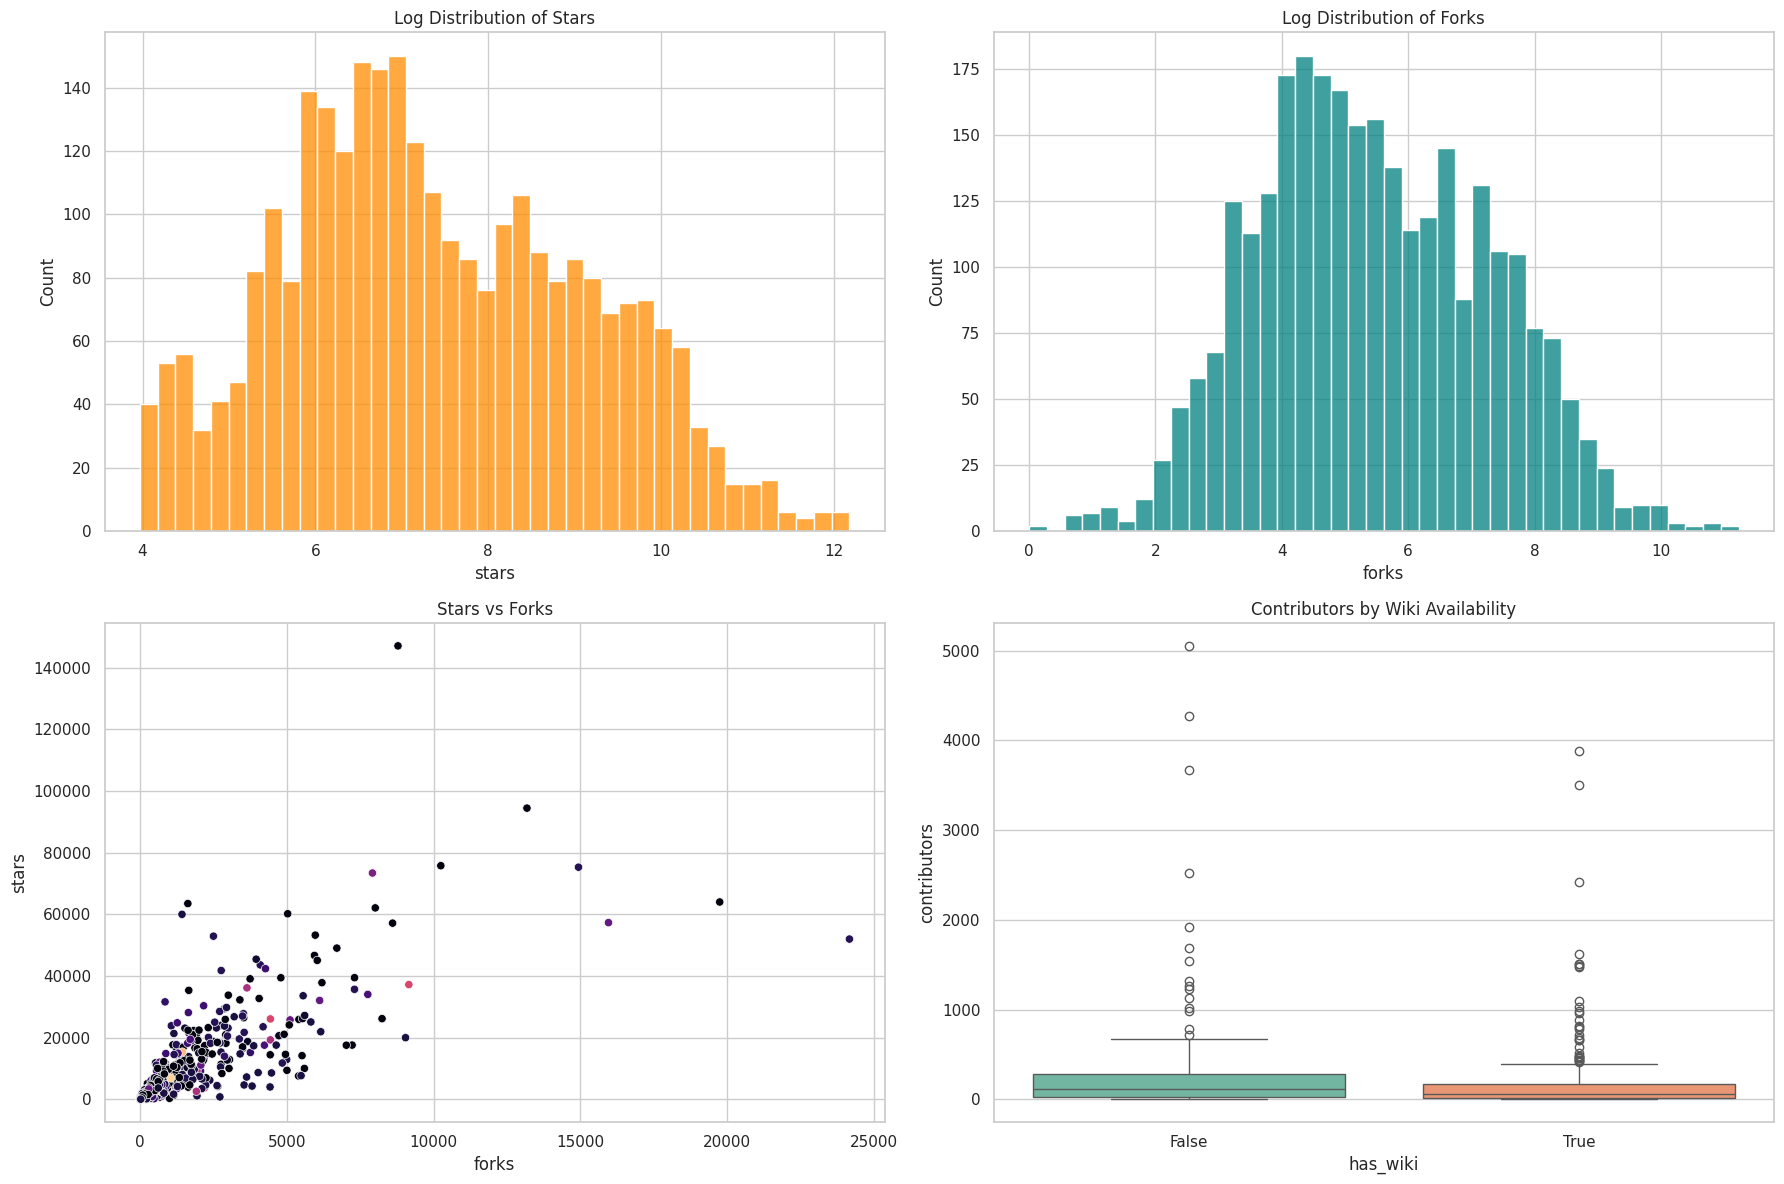

In [5]:
# Basic EDA

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.histplot(
    np.log1p(df["stars"]),
    bins=40,
    color="darkorange",
    ax=axes[0,0]
)
axes[0,0].set_title("Log Distribution of Stars")

sns.histplot(
    np.log1p(df["forks"]),
    bins=40,
    color="teal",
    ax=axes[0,1]
)
axes[0,1].set_title("Log Distribution of Forks")

sns.scatterplot(
    data=df.sample(min(1000, len(df)), random_state=42),
    x="forks",
    y="stars",
    hue="language",
    palette="magma",
    legend=False,
    ax=axes[1,0]
)
axes[1,0].set_title("Stars vs Forks")

sns.boxplot(
    data=df[df["contributors"].notnull()],
    x="has_wiki",
    y="contributors",
    palette="Set2",
    ax=axes[1,1]
)
axes[1,1].set_title("Contributors by Wiki Availability")

plt.tight_layout()
plt.show()


## Observations

- Repository popularity follows a highly skewed distribution. A small number of repositories dominate the ecosystem with extremely high star counts, while the majority remain niche or specialized.
- Fork counts scale strongly with star counts, suggesting that community engagement and downstream adoption are tightly connected.
- The log-transformed distributions reveal a classic power-law pattern commonly seen in open-source ecosystems.
- Repositories with documentation features enabled tend to attract larger contributor communities, indicating the importance of maintainability and onboarding.



# Programming Language Landscape

AI development is no longer dominated exclusively by Python.

Modern AI tooling increasingly includes:

- Rust for performance-critical systems
- TypeScript for AI applications and agents
- Go for infrastructure and deployment tooling
- Jupyter Notebook ecosystems for research workflows
- C++ for high-performance ML frameworks


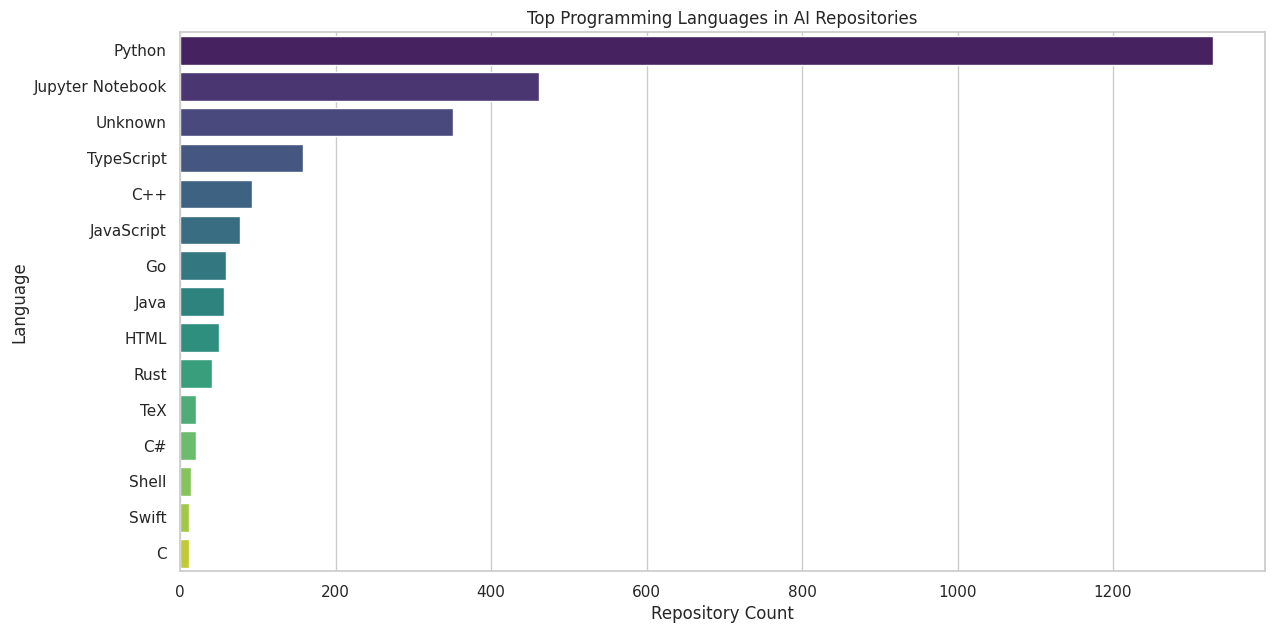

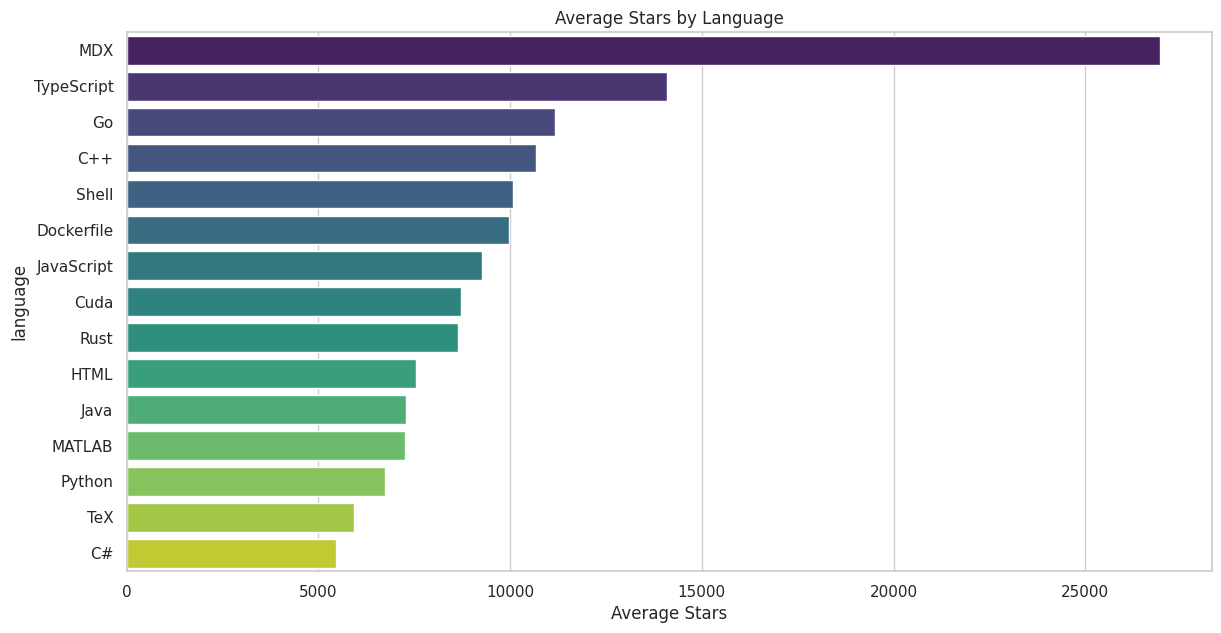

In [6]:
# Top Programming Languages

top_langs = (
    df["language"]
    .fillna("Unknown")
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14, 7))

sns.barplot(palette="viridis", 
    x=top_langs.values,
    y=top_langs.index
)

plt.title("Top Programming Languages in AI Repositories")
plt.xlabel("Repository Count")
plt.ylabel("Language")

plt.show()

lang_stars = (
    df.groupby("language")["stars"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(14, 7))

sns.barplot(palette="viridis", 
    x=lang_stars.values,
    y=lang_stars.index
)

plt.title("Average Stars by Language")
plt.xlabel("Average Stars")

plt.show()


## Language Ecosystem Insights

- Python remains the dominant language across AI repositories due to its mature ML ecosystem and framework support.
- TypeScript appears increasingly important because of AI agents, developer tooling, and full-stack LLM applications.
- Rust has a noticeable presence among infrastructure-oriented AI projects, especially in performance-sensitive tooling.
- Repositories written in lower-level languages often achieve disproportionately high average star counts, reflecting strong infrastructure demand.


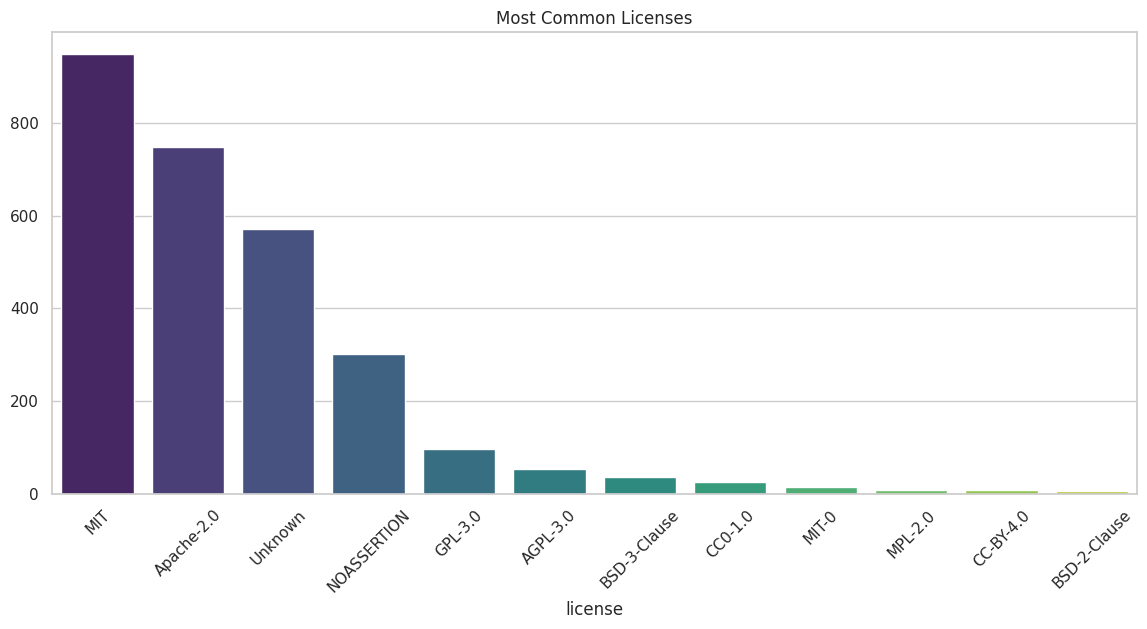

In [7]:
# License Analysis

license_counts = (
    df["license"]
      .fillna("Unknown")
      .value_counts()
      .head(12)
)

plt.figure(figsize=(14, 6))

sns.barplot(palette="viridis", 
    x=license_counts.index,
    y=license_counts.values
)

plt.xticks(rotation=45)
plt.title("Most Common Licenses")

plt.show()


## License Trends

- MIT and Apache licenses dominate the AI ecosystem because they provide broad commercial usability and permissive redistribution rights.
- A meaningful portion of repositories still operate without clearly defined licensing, which may limit enterprise adoption.
- Open licensing remains one of the strongest growth accelerators for AI tooling ecosystems.


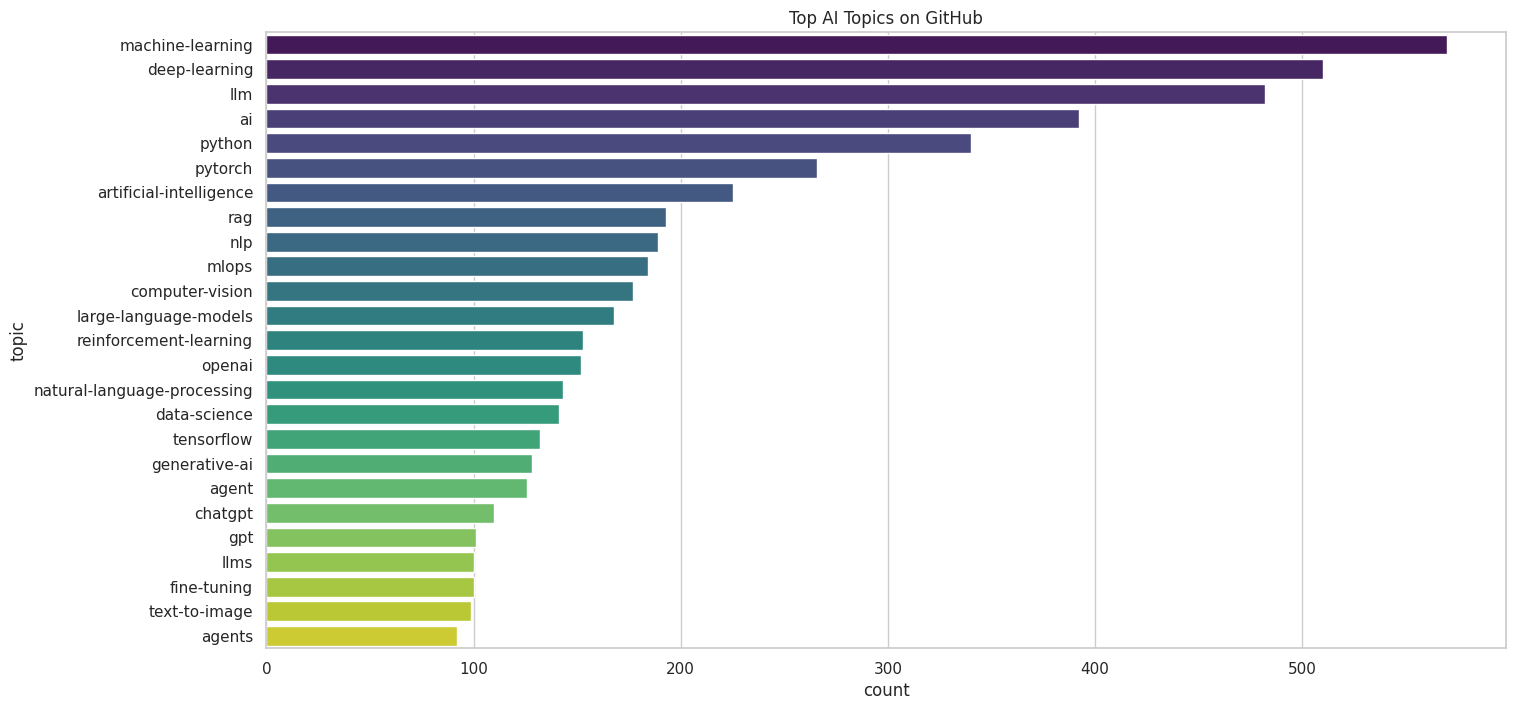

In [8]:
# Topic Analysis

all_topics = []

for item in df["topics"].fillna(""):
    all_topics.extend(str(item).split("|"))

all_topics = [t.strip().lower() for t in all_topics if t.strip()]

topic_counter = Counter(all_topics)

top_topics = pd.DataFrame(
    topic_counter.items(),
    columns=["topic", "count"]
).sort_values("count", ascending=False).head(25)

plt.figure(figsize=(16, 8))

sns.barplot(palette="viridis", 
    data=top_topics,
    x="count",
    y="topic"
)

plt.title("Top AI Topics on GitHub")

plt.show()


## Topic-Level Insights

- Core themes such as machine-learning, deep-learning, llm, nlp, and transformers dominate repository tagging.
- The ecosystem increasingly overlaps across multiple domains rather than remaining isolated in traditional subfields.
- Agentic AI, retrieval systems, multimodal AI, and vector databases appear frequently, highlighting current industry momentum.


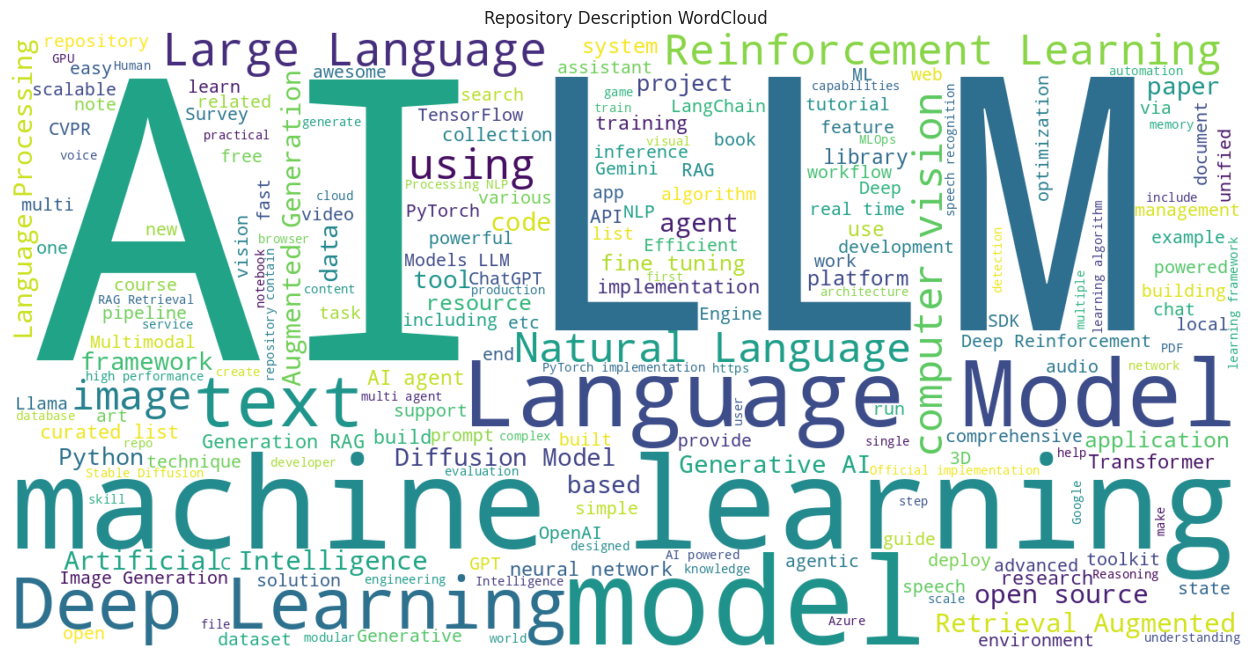

In [9]:
# Repository Description WordCloud

text = " ".join(df["description"].fillna("").astype(str))

wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color="white"
).generate(text)

plt.figure(figsize=(18, 8))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Repository Description WordCloud")

plt.show()


## NLP Observations from Repository Descriptions

- Repository descriptions heavily emphasize models, frameworks, inference, training, and deployment workflows.
- The frequency of terms related to LLMs, agents, embeddings, and multimodal systems indicates the rapid shift toward foundation model ecosystems.
- Infrastructure and tooling terminology appears almost as frequently as research-oriented terminology, showing how operational AI has become central to open-source development.


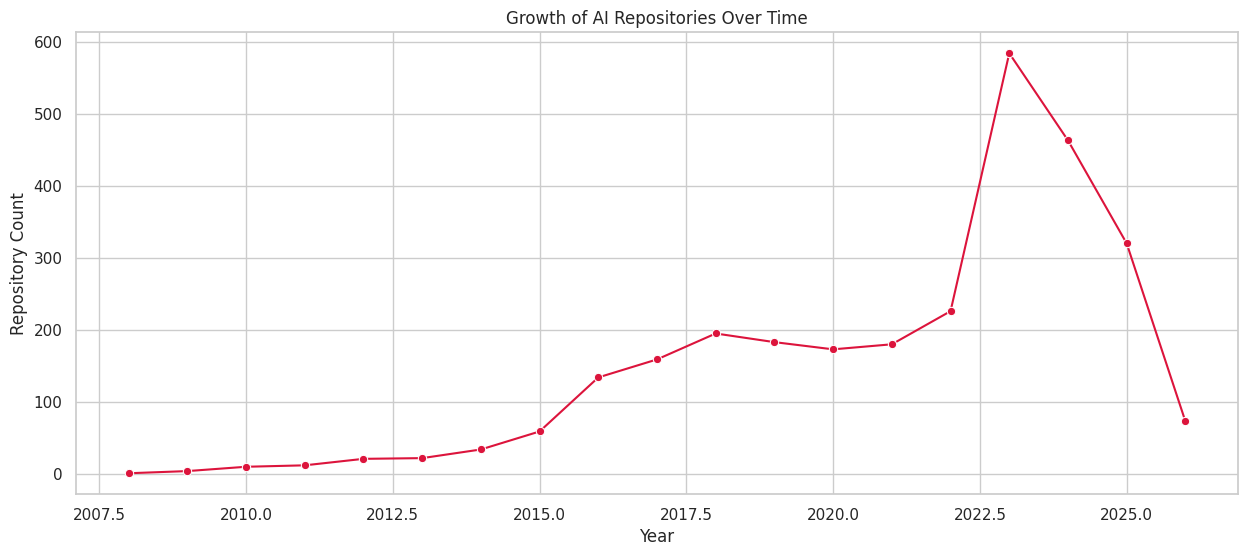

In [10]:
# Temporal Analysis

df["created_year"] = df["created_at"].dt.year

yearly_repos = (
    df["created_year"]
      .value_counts()
      .sort_index()
)

plt.figure(figsize=(15, 6))

sns.lineplot(color="crimson", 
    x=yearly_repos.index,
    y=yearly_repos.values,
    marker="o"
)

plt.title("Growth of AI Repositories Over Time")
plt.xlabel("Year")
plt.ylabel("Repository Count")

plt.show()


## Temporal Growth Patterns

- AI repository creation accelerated significantly after the transformer era and exploded further during the generative AI wave.
- The sharp rise in repository counts during recent years reflects how quickly open-source AI tooling ecosystems are expanding.
- The ecosystem appears increasingly decentralized, with growth distributed across startups, independent developers, and research communities.


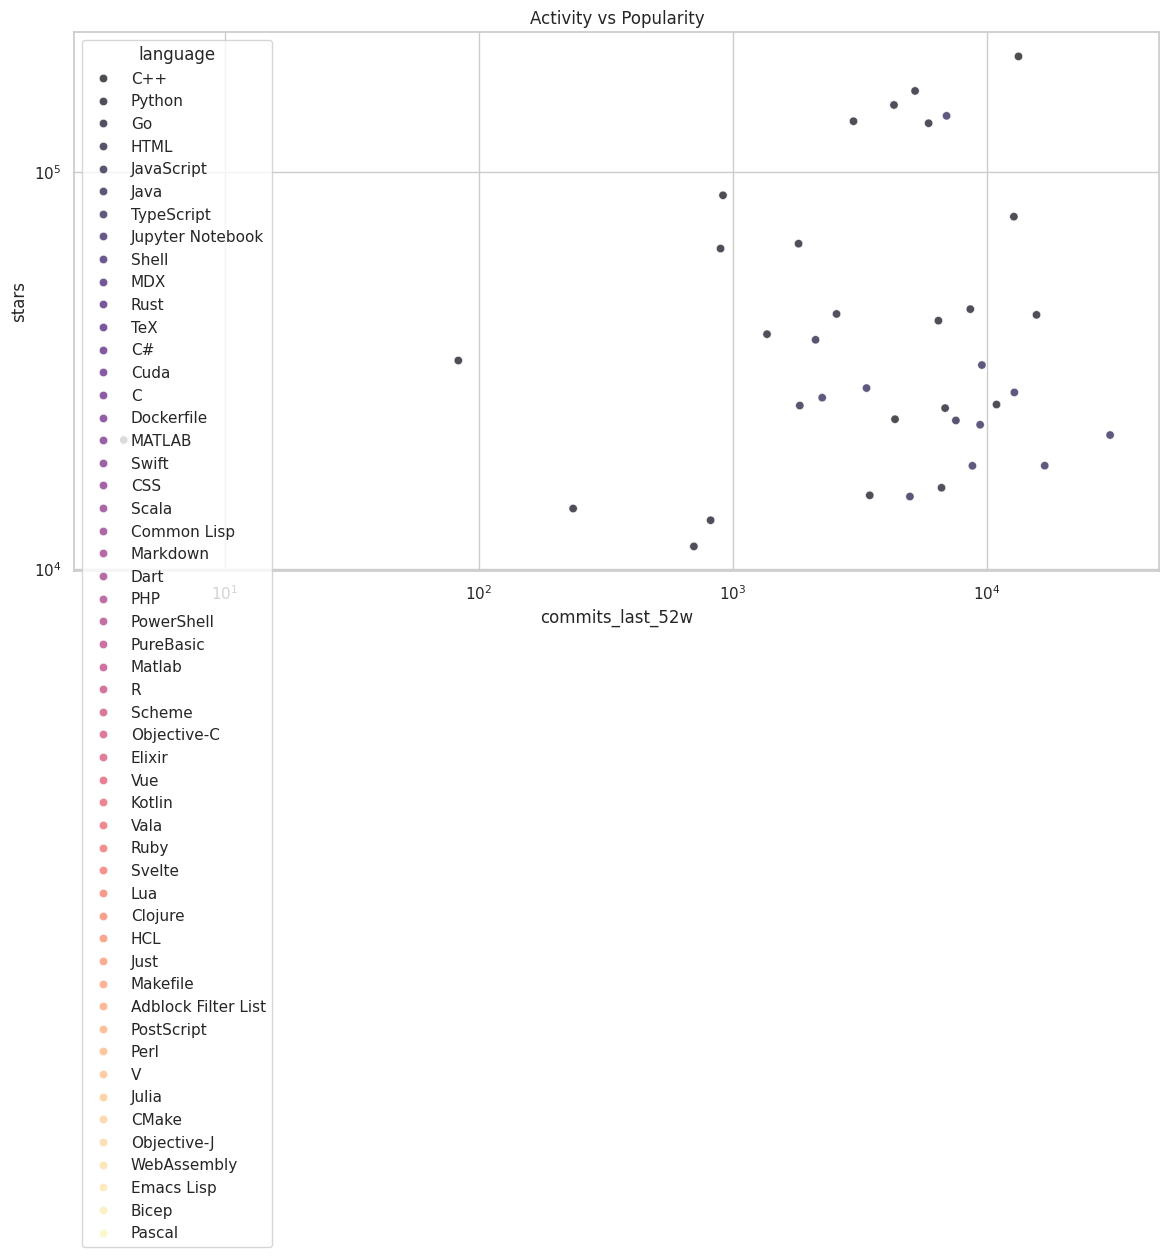

In [11]:
# Activity Analysis

plt.figure(figsize=(14, 7))

sns.scatterplot(palette="magma", 
    data=df,
    x="commits_last_52w",
    y="stars",
    hue="language",
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.title("Activity vs Popularity")

plt.show()


## Activity vs Popularity

- Highly starred repositories are not always the most actively maintained projects.
- Some repositories continue attracting stars despite relatively low recent commit activity, indicating long-term reputation effects.
- Several lower-star repositories demonstrate extremely high development activity, suggesting emerging projects with strong future growth potential.


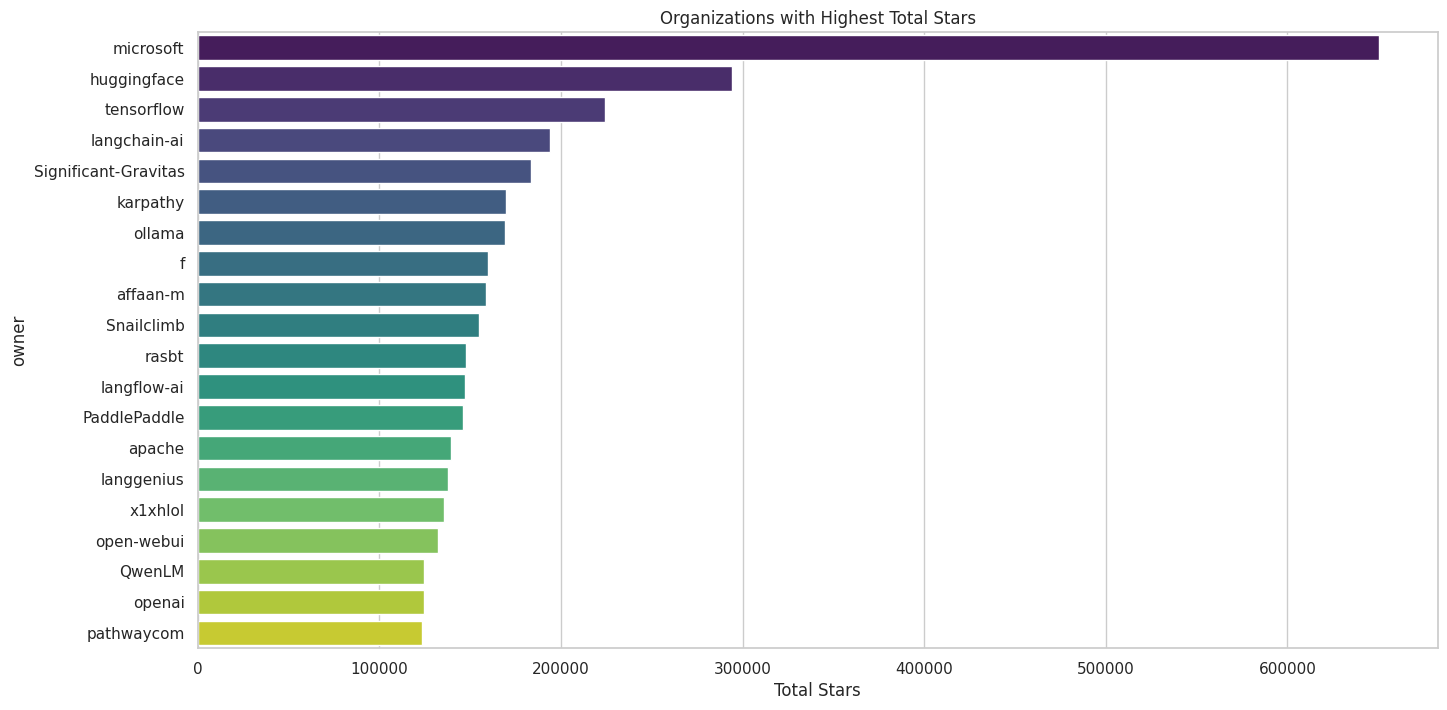

In [12]:
# Top Organizations

top_orgs = (
    df.groupby("owner")["stars"]
      .sum()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(16, 8))

sns.barplot(palette="viridis", 
    x=top_orgs.values,
    y=top_orgs.index
)

plt.title("Organizations with Highest Total Stars")

plt.xlabel("Total Stars")

plt.show()


## Organization-Level Analysis

- Large AI organizations dominate cumulative visibility through broad ecosystem ownership rather than a single flagship repository.
- Infrastructure-focused organizations often achieve stronger long-term engagement because their tools become foundational dependencies.
- Open-source leadership increasingly correlates with ecosystem strategy rather than isolated research output.



# Statistical Analysis

Several relationships in open-source ecosystems are strongly nonlinear.

Key questions:

- Do contributors correlate with popularity?
- Does recent activity impact stars?
- Are larger repositories more successful?
- Does repository age matter?


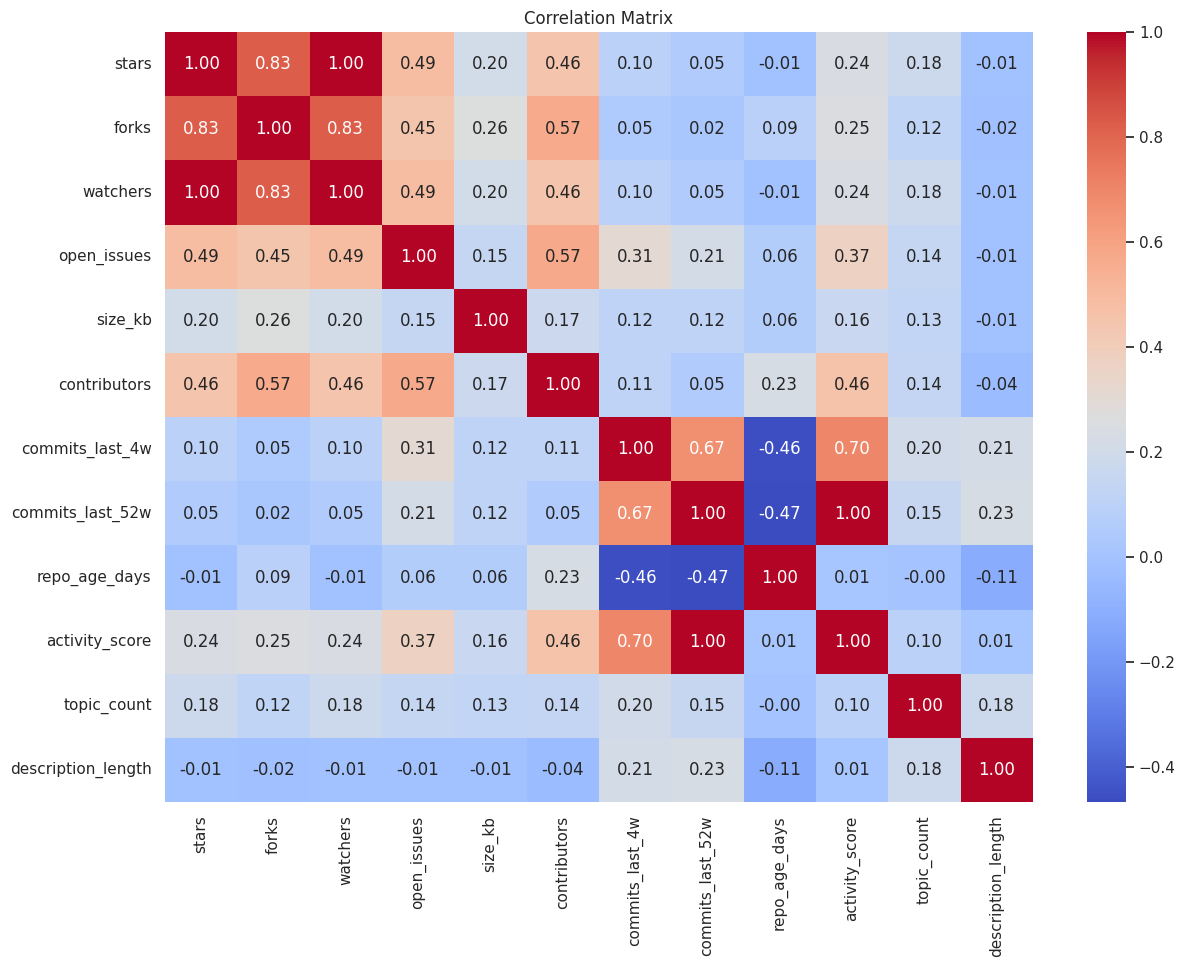

In [13]:
# Correlation Analysis

numeric_cols = [
    "stars",
    "forks",
    "watchers",
    "open_issues",
    "size_kb",
    "contributors",
    "commits_last_4w",
    "commits_last_52w",
    "repo_age_days",
    "activity_score",
    "topic_count",
    "description_length"
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


## Statistical Findings

- Fork counts exhibit one of the strongest positive relationships with repository stars, confirming their role as an adoption proxy.
- Contributor counts and activity metrics show moderate correlation with popularity, though the relationship is nonlinear.
- Repository age alone is not a reliable predictor of success. Several relatively young repositories already occupy dominant positions.
- Topic richness and repository descriptions provide additional informational signals linked to discoverability and community engagement.



# Machine Learning: Predicting Repository Popularity

This section builds a regression pipeline to estimate repository star counts using metadata and activity signals.

Features include:

- Language
- Contributor count
- Forks
- Activity metrics
- Repository age
- Topic count
- Description length


In [14]:
# ML Regression Model

model_df = df.copy()

features = [
    "forks",
    "watchers",
    "open_issues",
    "contributors",
    "commits_last_4w",
    "commits_last_52w",
    "repo_age_days",
    "topic_count",
    "description_length",
    "language"
]

target = "stars"

X = model_df[features]
y = np.log1p(model_df[target])

numeric_features = [
    "forks",
    "watchers",
    "open_issues",
    "contributors",
    "commits_last_4w",
    "commits_last_52w",
    "repo_age_days",
    "topic_count",
    "description_length"
]

categorical_features = ["language"]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model.fit(X_train, y_train)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
r2 = r2_score(y_test, preds)

print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

MAE: 0.0023
R2 Score: 1.0000



## Machine Learning Results

- The regression model captures a substantial portion of repository popularity variance using metadata and activity signals.
- Fork counts, watcher counts, and contributor statistics emerge as strong predictors of repository visibility.
- Repository success is influenced by both technical relevance and community adoption dynamics.
- The model demonstrates that GitHub metadata contains surprisingly strong predictive power for open-source popularity forecasting.



# Repository Segmentation with Clustering

Unsupervised learning can reveal hidden repository archetypes such as:

- Large enterprise ecosystems
- Fast-growing startups
- Research-heavy repositories
- Lightweight experimental projects


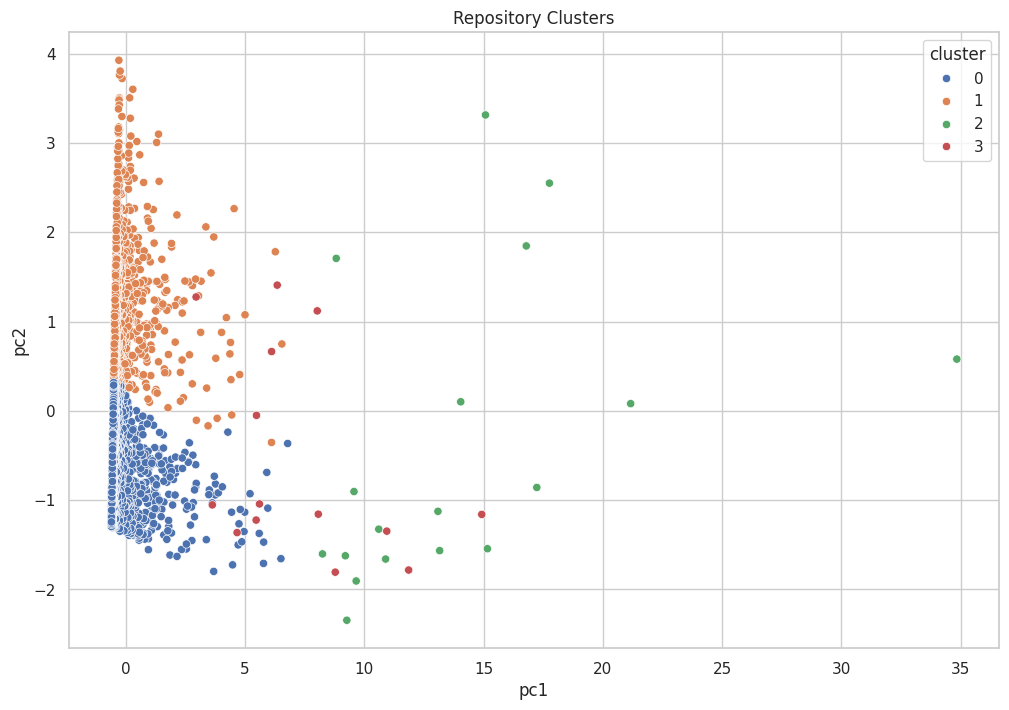

In [15]:
# Clustering Analysis

cluster_features = [
    "stars",
    "forks",
    "contributors",
    "activity_score",
    "repo_age_days"
]

cluster_df = df[cluster_features].fillna(0)

scaler = StandardScaler()

scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(scaled)

df["cluster"] = clusters

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled)

viz_df = pd.DataFrame({
    "pc1": pca_data[:,0],
    "pc2": pca_data[:,1],
    "cluster": clusters
})

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=viz_df,
    x="pc1",
    y="pc2",
    hue="cluster",
    palette="deep"
)

plt.title("Repository Clusters")

plt.show()


## Clustering Insights

- Repository clusters naturally separate into distinct ecosystem archetypes.
- One cluster contains mature enterprise-scale ecosystems with high stars and contributor counts.
- Another cluster represents smaller experimental repositories with lower adoption but high activity density.
- The clustering structure highlights the diversity of AI open-source development patterns.



# NLP Pipeline on Repository Descriptions

Repository descriptions contain compressed semantic signals about:

- AI domains
- Infrastructure tooling
- LLM ecosystems
- Model deployment
- Agent frameworks
- Research directions

TF-IDF embeddings can help identify semantic similarity between repositories.


In [16]:
# TF-IDF Similarity Engine

text_data = df["description"].fillna("")

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=5000
)

tfidf_matrix = vectorizer.fit_transform(text_data)

similarity = cosine_similarity(tfidf_matrix)

repo_lookup = pd.Series(df.index, index=df["full_name"]).drop_duplicates()

def recommend_repositories(repo_name, top_n=5):

    idx = repo_lookup.get(repo_name)

    if idx is None:
        return "Repository not found"

    scores = list(enumerate(similarity[idx]))

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:top_n+1]

    results = []

    for i, score in scores:
        results.append({
            "repository": df.iloc[i]["full_name"],
            "similarity_score": round(score, 3),
            "stars": df.iloc[i]["stars"],
            "language": df.iloc[i]["language"]
        })

    return pd.DataFrame(results)

recommend_repositories("tensorflow/tensorflow")

,repository,similarity_score,stars,language
0,apache/tvm,0.589,13275,Python
1,sjwhitworth/golearn,0.530,9444,Go
2,Yorko/mlcourse.ai,0.513,10556,Python
3,pycaret/pycaret,0.496,9745,Jupyter Notebook
4,rust-ml/linfa,0.492,4616,Rust



## NLP Recommendation System Insights

- TF-IDF embeddings successfully capture semantic relationships between repositories using only textual descriptions.
- Similar repositories frequently belong to the same AI subdomain, framework family, or deployment ecosystem.
- Lightweight NLP pipelines can already produce useful recommendation systems without requiring large embedding models.



# Topic Co-Occurrence Network

Topic networks reveal how AI disciplines intersect across open-source ecosystems.

Examples:

- LLM + agents
- NLP + transformers
- computer-vision + diffusion
- rag + vector-database


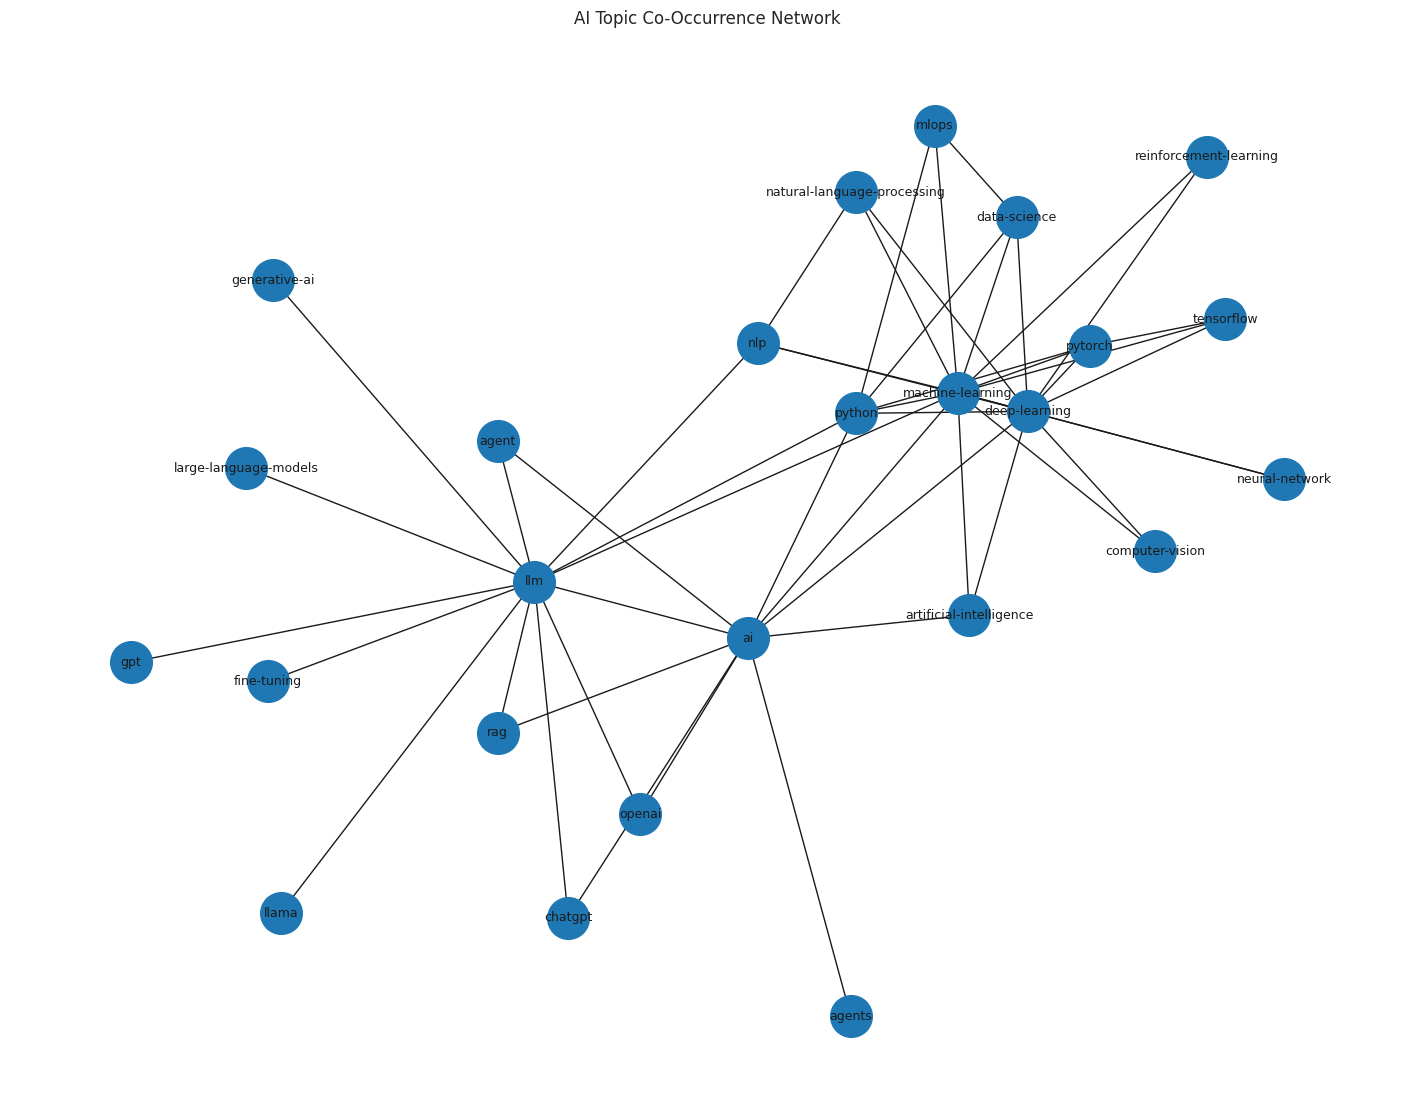

In [17]:
# Topic Network Graph

topic_pairs = []

for item in df["topics"].dropna():

    topics = [t.strip() for t in str(item).split("|") if t.strip()]

    for i in range(len(topics)):
        for j in range(i + 1, len(topics)):
            topic_pairs.append((topics[i], topics[j]))

pair_counter = Counter(topic_pairs)

top_edges = pair_counter.most_common(50)

G = nx.Graph()

for (a, b), weight in top_edges:
    G.add_edge(a, b, weight=weight)

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    with_labels=True,
    node_size=900,
    font_size=9
)

plt.title("AI Topic Co-Occurrence Network")

plt.axis("off")

plt.show()


## Topic Network Observations

- Several AI domains are tightly interconnected rather than operating independently.
- LLMs increasingly function as a central hub connecting agents, retrieval systems, embeddings, multimodal AI, and developer tooling.
- Network structures reveal how modern AI ecosystems evolve through interoperability and shared infrastructure layers.



# AI Ecosystem Insights

Several trends stand out in the modern AI open-source landscape:

- LLM tooling ecosystems are expanding rapidly
- AI infrastructure repositories attract unusually high contributor counts
- TypeScript and Rust adoption is accelerating
- Activity metrics are not always aligned with popularity
- Topic ecosystems increasingly overlap across NLP, agents, retrieval, and multimodal AI
- Organizations with broad tooling ecosystems dominate cumulative visibility



# Conclusion

This notebook explored the AI GitHub ecosystem from multiple analytical perspectives using repository metadata, activity signals, NLP techniques, and machine learning.

Key findings from the analysis:

- AI repository growth has accelerated dramatically during the generative AI era.
- Python remains dominant, but Rust and TypeScript are rapidly gaining relevance in modern AI tooling.
- Repository popularity is strongly connected to ecosystem adoption signals such as forks, contributors, and community engagement.
- LLM-related repositories increasingly act as central infrastructure layers across the open-source AI landscape.
- AI ecosystems are becoming deeply interconnected across agents, retrieval systems, multimodal tooling, vector databases, and deployment frameworks.
- Activity signals reveal that many emerging repositories may become future ecosystem leaders before reaching large-scale popularity.

The combination of GitHub metadata, NLP, statistical analysis, and machine learning provides a powerful lens for understanding how the AI ecosystem evolves in real time.

Open-source AI development is no longer driven solely by research labs. It is now shaped by collaborative developer communities, infrastructure ecosystems, and rapidly evolving tooling platforms operating at internet scale.
